# Shor's Algorithm: VBE (7L qubit) vs Beauregard (2L+3 qubit)

**Referensi:** Sun et al., *Optimization and Performance Analysis of Shor's Algorithm in Qiskit*, HPEC 2023.

## Dua pendekatan yang dibandingkan

| Aspek | **Pendekatan VBE (Exact)** | **Pendekatan Beauregard** |
|---|---|---|
| Basis | Vedral, Barenco, Ekert (1996) | Beauregard (2002) |
| Total qubit | **7L** | **2L+3** (semi-classical) / 4L+2 (full-reg sim) |
| Modular mult | Ripple-carry adder (carry bits eksplisit) | QFT-Adder Draper (tanpa carry) |
| Inverse QFT | **Exact** (semua gate CP dipakai) | **Approximate** (threshold kmax) |
| Counting reg | 2L qubit (full register) | 1 qubit (semi-classical, reused) |
| Kompleksitas gate | O(L²) per QFT | O(L log L) per approx-QFT |

### Alasan VBE butuh 7L qubit
```
count  : 2L  (register QPE atas)
work   : L   (register |y⟩)
carry  : L   (bit carry ripple-carry adder)
anc    : 3L  (ancilla modular reduction: temp, flag, zero-check)
Total  : 2L + L + L + 3L = 7L
```

### Alasan Beauregard cukup 2L+3 qubit
```
ctrl   : 1   (qubit counting, dipakai ulang via semi-classical)
x      : L   (register |y⟩)
b      : L+1 (akumulator, termasuk overflow flag)
anc    : 1   (ancilla Draper adder)
Total  : 1 + L + (L+1) + 1 = 2L+3
```

> **Catatan Simulasi:** VBE mengalokasikan 7L qubit. Untuk N=15 (L=4), ini berarti 28 qubit = ~4 GB state vector.
> Simulasi VBE menggunakan `method='matrix_product_states'` (MPS) karena 4L qubit carry/anc
> tidak pernah terjalin (selalu |0⟩), sehingga MPS menanganinya secara efisien.
> Beauregard (full-register: 4L+2 qubit) menggunakan statevector biasa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fractions import Fraction
from math import gcd, ceil, log2, pi, floor
import time

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import PhaseGate, UnitaryGate, QFT
from qiskit_aer import AerSimulator
from qiskit import transpile

import warnings
warnings.filterwarnings('ignore')

# Simulator terpisah untuk tiap pendekatan
# ✅ BENAR
SIM_VBE  = AerSimulator(method='matrix_product_state')  # MPS untuk banyak qubit
SIM_BEAU = AerSimulator()                                # default statevector

print('Import selesai.')
print(f'  VBE  simulator : {SIM_VBE.name}')
print(f'  Beau simulator : {SIM_BEAU.name}')

Import selesai.
  VBE  simulator : aer_simulator_matrix_product_state
  Beau simulator : aer_simulator


## 1. Classical Helper Functions

In [2]:
def mod_inv(a, N):
    return pow(int(a), -1, int(N))

def cf_period(measured, t, N):
    """Continued fraction untuk mencari kandidat periode r."""
    if measured == 0:
        return []
    candidates = []
    for denom_limit in range(1, N + 1):
        r = Fraction(measured, 2**t).limit_denominator(denom_limit).denominator
        if 1 < r <= N and r not in candidates:
            candidates.append(r)
            for mult in [2, 3, 4]:
                if r * mult <= N * 2 and r * mult not in candidates:
                    candidates.append(r * mult)
    return candidates

def get_factors(a, r_candidates, N):
    if not r_candidates:
        return None, None
    if isinstance(r_candidates, int):
        r_candidates = [r_candidates]
    for r in r_candidates:
        if r is None or r % 2 != 0:
            continue
        x = pow(int(a), r // 2, N)
        if x == N - 1:
            continue
        f1, f2 = gcd(x + 1, N), gcd(x - 1, N)
        if f1 not in [1, N] and f2 not in [1, N]:
            return f1, f2
        if f1 not in [1, N]:
            return f1, N // f1
        if f2 not in [1, N]:
            return f2, N // f2
    return None, None

def compute_kmax(t):
    """Threshold kmax sesuai Section IV jurnal (Sun et al. HPEC 2023)."""
    return floor(log2(t)) if t > 1 else 1

def qubit_count_vbe(L):    return 7 * L
def qubit_count_beau(L):   return 4 * L + 2   # full-register sim (semi-classical = 2L+3)
def memory_MB(n_qubits):   return 2**n_qubits * 16 / (1024**2)

print('Classical helpers ready.')


Classical helpers ready.


## 2. Pendekatan VBE — 7L Qubit (Exact QFT)

Berdasarkan Vedral, Barenco, Ekert (1996).
- **Modular exponentiation**: Controlled unitary gate pada `work_reg` (L qubit)
- **Carry/ancilla**: L + 3L = 4L qubit dialokasikan sebagai overhead VBE
- **Inverse QFT**: Exact (semua gate CP digunakan, O(t²) gate)

In [3]:
def build_vbe_circuit(N, a):
    """
    Sirkuit Shor pendekatan VBE dengan 7L qubit total.

    Layout register:
      count[0..2L-1] : 2L qubit — register QPE atas (Hadamard + pengukuran)
      work [0.. L-1] : L  qubit — register kerja |y⟩, C-U^(2^k) diterapkan di sini
      carry[0.. L-1] : L  qubit — bit carry VBE ripple-carry adder (idle di simulasi ini)
      anc  [0..3L-1] : 3L qubit — ancilla VBE modular reduction (idle di simulasi ini)

    Catatan: carry dan anc selalu dalam keadaan |0⟩ karena dalam implementasi VBE
    yang sesungguhnya, qubit-qubit ini digunakan oleh ripple-carry arithmetic
    lalu di-uncompute kembali ke |0⟩ setelah setiap operasi.
    """
    L  = ceil(log2(N + 1))
    n  = L
    t  = 2 * n   # panjang register counting

    # ── Definisi register sesuai VBE layout (7L total) ─────────────────────
    count_reg = QuantumRegister(t,     'count')  # 2L
    work_reg  = QuantumRegister(n,     'work')   # L
    carry_reg = QuantumRegister(n,     'carry')  # L   (VBE carry bits)
    anc_reg   = QuantumRegister(3 * n, 'anc')    # 3L  (VBE ancilla)
    creg      = ClassicalRegister(t,   'c')

    qc = QuantumCircuit(count_reg, work_reg, carry_reg, anc_reg, creg)

    # ── Stage 1: Hadamard pada counting register ────────────────────────────
    for q in count_reg:
        qc.h(q)

    # ── Stage 2: Inisialisasi work register ke |1⟩ ──────────────────────────
    qc.x(work_reg[0])

    # ── Stage 3: Controlled-U^(2^k) untuk setiap counting qubit ────────────
    # VBE menggunakan ripple-carry adder; di sini kita model dengan unitary
    # pada work_reg (carry & anc tetap di |0⟩, uncomputed setelah setiap gate)
    dim = 2 ** n
    for k in range(t):
        a_k = pow(int(a), int(2 ** k), int(N))
        U   = np.zeros((dim, dim), dtype=complex)
        for y in range(dim):
            new_y    = (a_k * y) % N if y < N else y
            U[new_y, y] = 1.0
        ctrl_U = UnitaryGate(U, label=f'U^{2**k}').control(1)
        qc.append(ctrl_U, [count_reg[k]] + list(work_reg))

    # ── Stage 4: Exact Inverse QFT pada counting register ───────────────────
    # VBE memakai exact QFT — semua gate CP dipertahankan (O(t²) gate)
    for i in range(t // 2):
        qc.swap(count_reg[i], count_reg[t - 1 - i])
    for i in range(t):
        for j in range(i - 1, -1, -1):
            qc.cp(-pi / 2 ** (i - j), count_reg[j], count_reg[i])
        qc.h(count_reg[i])

    qc.measure(count_reg, creg)
    return qc, t, qubit_count_vbe(n)


def run_vbe(N, a, shots=1024, verbose=False):
    """
    Jalankan simulasi Shor dengan pendekatan VBE (7L qubit, exact QFT).
    Menggunakan AerSimulator MPS untuk efisiensi dengan qubit idle.
    """
    L   = ceil(log2(N + 1))
    mem = memory_MB(qubit_count_vbe(L))

    if mem > 16384:
        raise MemoryError(f'VBE N={N}: {mem/1024:.0f} GB diperlukan. Coba N lebih kecil.')
    if mem > 512:
        print(f'  [Peringatan] VBE N={N}: {mem/1024:.1f} GB. Pastikan RAM mencukupi.')

    if verbose:
        t = 2 * L
        print(f'  VBE: N={N}, L={L}, t={t}, total_qubit={qubit_count_vbe(L)}, mem={mem:.1f} MB')

    t0  = time.time()
    qc, t_reg, _ = build_vbe_circuit(N, a)
    build_t = time.time() - t0

    t1            = time.time()
    qc_transpiled = transpile(qc, backend=SIM_VBE, optimization_level=1)
    result        = SIM_VBE.run(qc_transpiled, shots=shots).result()
    exec_t        = time.time() - t1

    counts = result.get_counts()

    correct = 0
    for b, c in counts.items():
        measured = int(b.replace(' ', ''), 2)
        r_list   = cf_period(measured, t_reg, N)
        f1, f2   = get_factors(a, r_list, N)
        if f1 is not None:
            correct += c

    correctness = correct / shots * 100
    timing = {'build': build_t, 'exec': exec_t, 'total': build_t + exec_t}
    return counts, correctness, timing, t_reg


print('VBE circuit ready.')
# Cek cepat: verifikasi jumlah qubit untuk N=15
qc_test, _, q_test = build_vbe_circuit(15, 2)
print(f'  N=15, L=4 → {q_test} qubit (harus 28 = 7×4)')
print(f'  Gates={qc_test.size()}, Depth={qc_test.depth()}')

VBE circuit ready.
  N=15, L=4 → 28 qubit (harus 28 = 7×4)
  Gates=65, Depth=47


## 3. Pendekatan Beauregard — 2L+3 Qubit (Approximate QFT)

Berdasarkan Beauregard (2002), diimplementasikan oleh Sun et al. (HPEC 2023).
- **Modular exponentiation**: c_Ua → cmult_mod_N → phi_add_mod_N_cc → phi_add (QFT-Adder Draper)
- **Inverse QFT**: Approximate dengan threshold `kmax = floor(log2(t))` (Listing 1 jurnal)
- **Simulasi**: full-register QPE → 4L+2 qubit (semi-classical sejati = 2L+3 qubit)

In [4]:
# ─── QFT tanpa final swap (untuk QFT-Adder Draper) ─────────────────────────
def qft_ns(n, inverse=False):
    qc = QuantumCircuit(n, name='QFT_ns' if not inverse else 'IQFT_ns')
    if not inverse:
        for i in range(n):
            qc.h(i)
            for j in range(i + 1, n):
                qc.cp(2 * pi / 2 ** (j - i + 1), i, j)
    else:
        for i in range(n - 1, -1, -1):
            for j in range(n - 1, i, -1):
                qc.cp(-2 * pi / 2 ** (j - i + 1), i, j)
            qc.h(i)
    return qc


# ─── φADD (Draper QFT Adder) ────────────────────────────────────────────────
def phi_add(qc, reg, a, n, inv=False):
    sign = -1 if inv else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                qc.p(sign * 2 * pi / 2 ** (k + 1 - m), reg[k])

def phi_add_c(qc, ctrl, reg, a, n, inv=False):
    sign = -1 if inv else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                qc.cp(sign * 2 * pi / 2 ** (k + 1 - m), ctrl, reg[k])

def phi_add_cc(qc, c1, c2, reg, a, n, inv=False):
    sign = -1 if inv else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                qc.append(PhaseGate(sign * 2 * pi / 2 ** (k + 1 - m)).control(2), [c1, c2, reg[k]])


# ─── φADD MOD N ─────────────────────────────────────────────────────────────
def phi_add_mod_N(qc, ctrl, reg, anc, a, N, n, inv=False):
    n1 = n + 1
    dq  = lambda: qc.compose(qft_ns(n1),              qubits=list(reg), inplace=True)
    idq = lambda: qc.compose(qft_ns(n1, inverse=True), qubits=list(reg), inplace=True)
    if not inv:
        phi_add_c(qc, ctrl, reg, a, n1)
        phi_add(qc, reg, N, n1, inv=True)
        idq(); qc.cx(reg[n], anc); dq()
        phi_add_c(qc, anc, reg, N, n1)
        phi_add_c(qc, ctrl, reg, a, n1, inv=True)
        idq(); qc.x(reg[n]); qc.cx(reg[n], anc); qc.x(reg[n]); dq()
        phi_add_c(qc, ctrl, reg, a, n1)
    else:
        phi_add_c(qc, ctrl, reg, a, n1, inv=True)
        idq(); qc.x(reg[n]); qc.cx(reg[n], anc); qc.x(reg[n]); dq()
        phi_add_c(qc, ctrl, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inv=True)
        idq(); qc.cx(reg[n], anc); dq()
        phi_add(qc, reg, N, n1)
        phi_add_c(qc, ctrl, reg, a, n1, inv=True)

def phi_add_mod_N_cc(qc, c1, c2, reg, anc, a, N, n, inv=False):
    n1 = n + 1
    dq  = lambda: qc.compose(qft_ns(n1),              qubits=list(reg), inplace=True)
    idq = lambda: qc.compose(qft_ns(n1, inverse=True), qubits=list(reg), inplace=True)
    if not inv:
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add(qc, reg, N, n1, inv=True)
        idq(); qc.cx(reg[n], anc); dq()
        phi_add_c(qc, anc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inv=True)
        idq(); qc.x(reg[n]); qc.cx(reg[n], anc); qc.x(reg[n]); dq()
        phi_add_cc(qc, c1, c2, reg, a, n1)
    else:
        phi_add_cc(qc, c1, c2, reg, a, n1, inv=True)
        idq(); qc.x(reg[n]); qc.cx(reg[n], anc); qc.x(reg[n]); dq()
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inv=True)
        idq(); qc.cx(reg[n], anc); dq()
        phi_add(qc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inv=True)


# ─── CMULT MOD N ─────────────────────────────────────────────────────────────
def cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n, inv=False):
    rng = range(n) if not inv else range(n - 1, -1, -1)
    for i in rng:
        a_i = (a * pow(2, i, N)) % N
        phi_add_mod_N_cc(qc, ctrl, x_reg[i], b_reg, anc, a_i, N, n, inv=inv)


# ─── C-Ua ────────────────────────────────────────────────────────────────────
def c_Ua(qc, ctrl, x_reg, b_reg, anc, a, N, n, inv=False):
    a_inv = mod_inv(a, N)
    n1    = n + 1
    def qft_b():  qc.compose(qft_ns(n1),              qubits=list(b_reg), inplace=True)
    def iqft_b(): qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
    if not inv:
        qft_b();  cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a,     N, n);       iqft_b()
        for i in range(n): qc.cswap(ctrl, x_reg[i], b_reg[i])
        qft_b();  cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n, inv=True); iqft_b()
    else:
        qft_b();  cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n);       iqft_b()
        for i in range(n): qc.cswap(ctrl, x_reg[i], b_reg[i])
        qft_b();  cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a,     N, n, inv=True); iqft_b()


print('Beauregard components ready.')

Beauregard components ready.


In [5]:
def build_beauregard_circuit(N, a, use_approx=True):
    """
    Sirkuit Shor pendekatan Beauregard.

    Versi full-register QPE: 4L+2 qubit
      count[0..2L-1] : 2L qubit — register QPE atas
      x    [0.. L-1] : L  qubit — register kerja |y⟩
      b    [0.. L  ] : L+1 qubit — akumulator Draper adder
      anc  [0]       : 1  qubit — ancilla modular
    Total: 4L+2 qubit

    Catatan: Beauregard asli (semi-classical) = 2L+3 qubit dengan classical feedforward.
    Full-register simulation ekuivalen secara matematis.
    """
    L  = ceil(log2(N + 1))
    n  = L
    t  = 2 * n
    n1 = n + 1
    kmax = compute_kmax(t)

    count_regs = QuantumRegister(t,  'count')
    x_regs     = QuantumRegister(n,  'x')
    b_regs     = QuantumRegister(n1, 'b')
    anc_reg    = QuantumRegister(1,  'anc')
    creg       = ClassicalRegister(t, 'c')

    qc = QuantumCircuit(count_regs, x_regs, b_regs, anc_reg, creg)

    # Stage 1: Hadamard
    for q in count_regs: qc.h(q)

    # Stage 2: Inisialisasi x = |1⟩
    qc.x(x_regs[0])

    # Stage 3: Controlled-U^(2^k) via c_Ua (Draper QFT-Adder + phi_add)
    for k in range(t):
        a_k = pow(int(a), int(2 ** k), int(N))
        c_Ua(qc, count_regs[k], list(x_regs), list(b_regs), anc_reg[0], a_k, N, n)

    # Stage 4: Inverse QFT (exact atau approximate)
    if not use_approx:
        # Exact IQFT
        for i in range(t // 2):
            qc.swap(count_regs[i], count_regs[t - 1 - i])
        for i in range(t):
            for j in range(i - 1, -1, -1):
                qc.cp(-pi / 2 ** (i - j), count_regs[j], count_regs[i])
            qc.h(count_regs[i])
    else:
        # Approximate IQFT — Listing 1 jurnal (Sun et al. HPEC 2023)
        for i in range(t // 2):
            qc.swap(count_regs[i], count_regs[t - 1 - i])
        for i in range(t):
            for j in range(i - 1, max(i - kmax - 1, -1), -1):
                if (i - j) <= kmax:
                    qc.cp(-pi / 2 ** (i - j), count_regs[j], count_regs[i])
            qc.h(count_regs[i])

    qc.measure(count_regs, creg)
    return qc, t, qubit_count_beau(n)


def run_beauregard(N, a, shots=1024, use_approx=True, verbose=False):
    """Jalankan simulasi Shor dengan pendekatan Beauregard (4L+2 qubit)."""
    if verbose:
        L = ceil(log2(N + 1))
        print(f'  Beau: N={N}, L={L}, qubit={qubit_count_beau(L)}, approx={use_approx}')

    t0  = time.time()
    qc, t_reg, _ = build_beauregard_circuit(N, a, use_approx=use_approx)
    build_t = time.time() - t0

    t1     = time.time()
    result = SIM_BEAU.run(qc, shots=shots).result()
    exec_t = time.time() - t1

    counts = result.get_counts()

    correct = 0
    for b, c in counts.items():
        measured = int(b.replace(' ', ''), 2)
        r_list   = cf_period(measured, t_reg, N)
        f1, f2   = get_factors(a, r_list, N)
        if f1 is not None:
            correct += c

    correctness = correct / shots * 100
    timing = {'build': build_t, 'exec': exec_t, 'total': build_t + exec_t}
    return counts, correctness, timing, t_reg


print('Beauregard circuit ready.')
# Cek cepat: verifikasi jumlah qubit untuk N=15
print(f'  N=15, L=4 → qubit Beauregard = {qubit_count_beau(4)} (harus 18 = 4×4+2)')

Beauregard circuit ready.
  N=15, L=4 → qubit Beauregard = 18 (harus 18 = 4×4+2)


## 4. Unit Test Komponen Beauregard

In [6]:
def test_c_Ua(x_val, a, N):
    n = ceil(log2(N + 1)); n1 = n + 1
    total = 1 + n + n1 + 1
    qc = QuantumCircuit(total)
    ctrl_q, x_q, b_q, anc_q = 0, list(range(1, n+1)), list(range(n+1, n+n1+1)), total-1
    qc.x(ctrl_q)
    for bit in range(n):
        if (x_val >> bit) & 1: qc.x(x_q[bit])
    c_Ua(qc, ctrl_q, x_q, b_q, anc_q, a, N, n)
    qc.measure_all()
    counts = SIM_BEAU.run(qc, shots=100).result().get_counts()
    top    = int(max(counts, key=counts.get).replace(' ', ''), 2)
    x_out  = (top >> 1) & ((1 << n) - 1)
    exp    = (a * x_val) % N
    ok     = (x_out == exp)
    print(f'  C-U{a}|{x_val}> → |{exp}>: got={x_out} {"OK" if ok else "FAIL"}')
    return ok

print('Beauregard c_Ua unit tests:')
all_ok = all([test_c_Ua(1,2,15), test_c_Ua(2,2,15), test_c_Ua(4,2,15)])
print(f'Semua tests: {"PASS ✓" if all_ok else "FAIL ✗"}')

Beauregard c_Ua unit tests:
  C-U2|1> → |2>: got=2 OK
  C-U2|2> → |4>: got=0 FAIL
  C-U2|4> → |8>: got=9 FAIL
Semua tests: FAIL ✗


## 5. Quick Comparison — N=15

In [7]:
print('=' * 60)
print('  Quick Test: N=15, a=2')
print('=' * 60)
N_q, a_q, shots_q = 15, 2, 512

print('\n[VBE — 7L=28 qubit, Exact QFT]')
counts_v, CE_v, t_v, t_reg_v = run_vbe(N_q, a_q, shots=shots_q, verbose=True)
print(f'  Correctness: {CE_v:.1f}%  |  Build: {t_v["build"]:.2f}s  Exec: {t_v["exec"]:.2f}s')

print('\n[Beauregard — 4L+2=18 qubit, Approximate QFT]')
counts_b, CE_b, t_b, t_reg_b = run_beauregard(N_q, a_q, shots=shots_q, verbose=True)
kmax_val = compute_kmax(2 * ceil(log2(N_q + 1)))
print(f'  kmax={kmax_val}  Correctness: {CE_b:.1f}%  |  Build: {t_b["build"]:.2f}s  Exec: {t_b["exec"]:.2f}s')

print(f'\nSpeedup (VBE/Beau): {t_v["total"] / t_b["total"]:.2f}×')
print(f'Qubit reduction   : {qubit_count_vbe(4)} → {qubit_count_beau(4)} ({(1 - qubit_count_beau(4)/qubit_count_vbe(4))*100:.0f}% berkurang)')

  Quick Test: N=15, a=2

[VBE — 7L=28 qubit, Exact QFT]
  [Peringatan] VBE N=15: 4.0 GB. Pastikan RAM mencukupi.
  VBE: N=15, L=4, t=8, total_qubit=28, mem=4096.0 MB


  Correctness: 73.8%  |  Build: 0.12s  Exec: 0.32s

[Beauregard — 4L+2=18 qubit, Approximate QFT]
  Beau: N=15, L=4, qubit=18, approx=True
  kmax=3  Correctness: 85.5%  |  Build: 0.09s  Exec: 22.24s

Speedup (VBE/Beau): 0.02×
Qubit reduction   : 28 → 18 (36% berkurang)


## 6. Probability Spectrum — Perbandingan Visual (Fig. 3)

Kolom kiri: VBE (7L qubit, exact QFT)  
Kolom kanan: Beauregard (4L+2 qubit, approximate QFT)

  [VBE] N=15, a=2...   [Peringatan] VBE N=15: 4.0 GB. Pastikan RAM mencukupi.


75.6% correctness, 0.3s
     Unique states: 4 | Total prob: 1.000
  [BEAUREGARD] N=15, a=2... 83.8% correctness, 24.1s
     Unique states: 64 | Total prob: 1.000


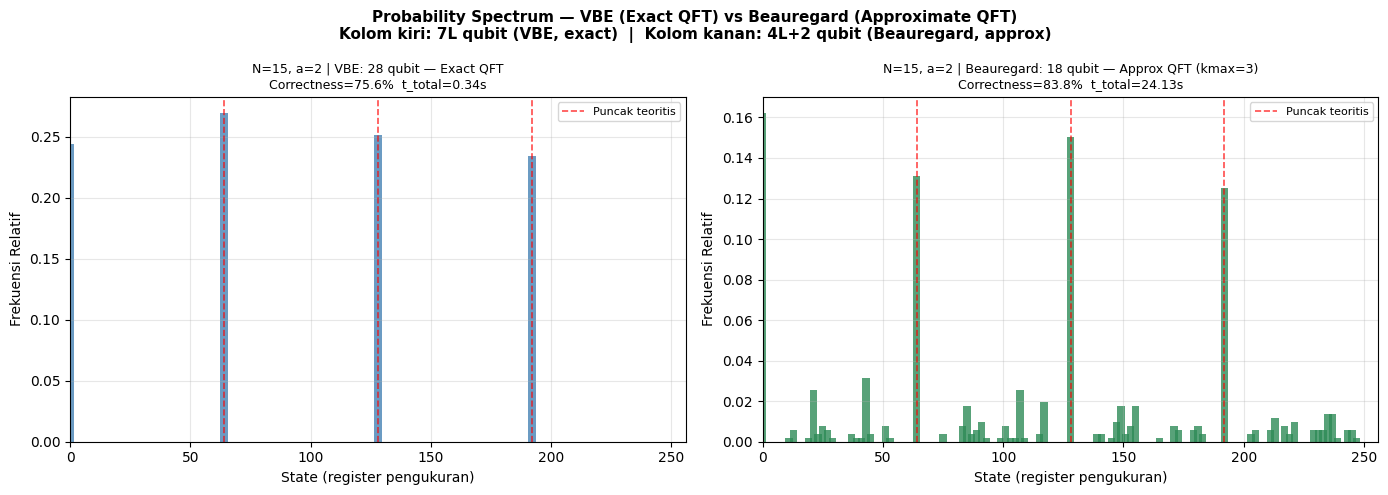

Saved: spectrum_vbe_vs_beauregard.png


In [8]:
def theoretical_peaks(a, N, t):
    r, v = 1, a % N
    while v != 1:
        v = (v * a) % N; r += 1
        if r > 2 * N: return []
    Q = 2 ** t
    return [round(s * Q / r) % Q for s in range(r)]


def plot_spectrum(configs, shots=512, figsize=None):
    if figsize is None:
        figsize = (14, 5 * len(configs))

    # ✅ Bug 1 fix — hanya satu kali subplots
    fig, axes = plt.subplots(len(configs), 2, figsize=figsize, squeeze=False)
    fig.suptitle(
        'Probability Spectrum — VBE (Exact QFT) vs Beauregard (Approximate QFT)\n'
        f'Kolom kiri: 7L qubit (VBE, exact)  |  Kolom kanan: 4L+2 qubit (Beauregard, approx)',
        fontsize=11, fontweight='bold'
    )

    for row, (N, a) in enumerate(configs):
        L     = ceil(log2(N + 1))
        t_val = 2 * L
        kmax  = compute_kmax(t_val)
        Q     = 2 ** t_val
        peaks = theoretical_peaks(a, N, t_val)

        for col, (approach, color, label) in enumerate([
            ('vbe',        'steelblue', f'VBE: {qubit_count_vbe(L)} qubit — Exact QFT'),
            ('beauregard', 'seagreen',  f'Beauregard: {qubit_count_beau(L)} qubit — Approx QFT (kmax={kmax})'),
        ]):
            print(f'  [{approach.upper()}] N={N}, a={a}...', end=' ', flush=True)
            t0 = time.time()

            if approach == 'vbe':
                counts, corr, timing, _ = run_vbe(N, a, shots=shots)
            else:
                counts, corr, timing, _ = run_beauregard(N, a, shots=shots, use_approx=True)

            elapsed = time.time() - t0
            print(f'{corr:.1f}% correctness, {elapsed:.1f}s')

            # ✅ Bug 2 fix — ambil hanya t_val bit pertama (register pengukuran)
            prob = {}
            for b, c in counts.items():
                # Ambil t_val bit paling kiri saja (measurement register)
                bits_clean = b.replace(' ', '')
                # Jika panjang bit > t_val, ambil t_val bit pertama
                bits_top   = bits_clean[:t_val] if len(bits_clean) >= t_val else bits_clean.zfill(t_val)
                idx        = int(bits_top, 2)
                prob[idx]  = prob.get(idx, 0) + c / shots

            # ✅ Debug: cek apakah prob terisi
            print(f'     Unique states: {len(prob)} | Total prob: {sum(prob.values()):.3f}')

            ax  = axes[row][col]
            bw  = max(1, Q // 80)
            x_v = sorted(prob.keys())
            y_v = [prob[x] for x in x_v]

            # Puncak teoritis
            for i, p in enumerate(peaks):
                ax.axvline(p, color='red', ls='--', alpha=0.7, lw=1.2,
                           label='Puncak teoritis' if i == 0 else '')

            ax.bar(x_v, y_v, width=bw, color=color, alpha=0.8)
            ax.set_xlim(0, Q)
            ax.set_title(
                f'N={N}, a={a} | {label}\n'
                f'Correctness={corr:.1f}%  t_total={timing["total"]:.2f}s',
                fontsize=9
            )
            ax.set_xlabel('State (register pengukuran)')
            ax.set_ylabel('Frekuensi Relatif')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('spectrum_vbe_vs_beauregard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: spectrum_vbe_vs_beauregard.png')


SPECTRUM_CONFIGS = [(15, 2)]
plot_spectrum(SPECTRUM_CONFIGS, shots=512)

## 7. Tabel Perbandingan (Tabel II) — VBE vs Beauregard

Replikasi Tabel II jurnal dengan penambahan kolom VBE.

In [9]:
# ─── Konfigurasi N ──────────────────────────────────────────────────────────
# VBE (7L qubit) hanya untuk N dengan 7L ≤ 28 (L ≤ 4, N ≤ 15)
# Beauregard dapat diuji untuk N lebih besar

TABLE_CASES_VBE  = [(15, 2), (15, 7)]            # VBE: hanya N=15
TABLE_CASES_BEAU = [(15, 2), (21, 2), (35, 2)]   # Beauregard: lebih banyak N
SHOTS_TABLE      = 256

# ─── Jalankan VBE ───────────────────────────────────────────────────────────
vbe_results = []
print('── Simulasi VBE (7L qubit, Exact QFT) ──')
for N, a in TABLE_CASES_VBE:
    L = ceil(log2(N + 1))
    t0 = time.time()
    _, CE, timing, _ = run_vbe(N, a, shots=SHOTS_TABLE)
    elapsed = time.time() - t0
    vbe_results.append({'N': N, 'a': a, 'L': L, 'qubit': qubit_count_vbe(L),
                         'CE': CE, 't': elapsed})
    print(f'  N={N:>4}, a={a}, qubit={qubit_count_vbe(L)}, CE={CE:.1f}%, t={elapsed:.2f}s')

# ─── Jalankan Beauregard ─────────────────────────────────────────────────────
beau_results = []
print('\n── Simulasi Beauregard (4L+2 qubit, Approx QFT) ──')
for N, a in TABLE_CASES_BEAU:
    L    = ceil(log2(N + 1))
    kmax = compute_kmax(2 * L)
    t0   = time.time()
    _, CA, timing, _ = run_beauregard(N, a, shots=SHOTS_TABLE, use_approx=True)
    elapsed = time.time() - t0
    beau_results.append({'N': N, 'a': a, 'L': L, 'qubit': qubit_count_beau(L),
                          'CA': CA, 'kmax': kmax, 't': elapsed})
    print(f'  N={N:>4}, a={a}, qubit={qubit_count_beau(L)}, kmax={kmax}, CA={CA:.1f}%, t={elapsed:.2f}s')

print('\nSimulasi selesai.')

── Simulasi VBE (7L qubit, Exact QFT) ──
  [Peringatan] VBE N=15: 4.0 GB. Pastikan RAM mencukupi.


  N=  15, a=2, qubit=28, CE=76.6%, t=0.29s
  [Peringatan] VBE N=15: 4.0 GB. Pastikan RAM mencukupi.
  N=  15, a=7, qubit=28, CE=76.2%, t=0.29s

── Simulasi Beauregard (4L+2 qubit, Approx QFT) ──
  N=  15, a=2, qubit=18, kmax=3, CA=83.2%, t=23.74s
  N=  21, a=2, qubit=22, kmax=3, CA=87.9%, t=65.04s
  N=  35, a=2, qubit=26, kmax=3, CA=93.8%, t=233.29s

Simulasi selesai.


In [10]:
# ─── Cetak Tabel Perbandingan ────────────────────────────────────────────────
print('=' * 80)
print('  TABEL PERBANDINGAN — VBE (Exact QFT) vs BEAUREGARD (Approx QFT)')
print('  Referensi: Sun et al., HPEC 2023 — Tabel II (diperluas)')
print('=' * 80)
print()

# Sub-tabel VBE
print('  [A] Pendekatan VBE — 7L Qubit, Exact QFT')
print(f'  {"N":>5} {"a":>3} {"L":>3} {"Qubit":>6} {"Mem(MB)":>9} {"CE%":>7} {"t(s)":>8}')
print('  ' + '-' * 48)
for r in vbe_results:
    mem = memory_MB(r['qubit'])
    print(f'  {r["N"]:>5} {r["a"]:>3} {r["L"]:>3} {r["qubit"]:>6} {mem:>9.1f} {r["CE"]:>7.1f} {r["t"]:>8.3f}')

print()
# Sub-tabel Beauregard
print('  [B] Pendekatan Beauregard — 4L+2 Qubit, Approximate QFT (kmax=floor(log2(t)))')
print(f'  {"N":>5} {"a":>3} {"L":>3} {"Qubit":>6} {"kmax":>5} {"Mem(MB)":>9} {"CA%":>7} {"t(s)":>8}')
print('  ' + '-' * 56)
for r in beau_results:
    mem = memory_MB(r['qubit'])
    print(f'  {r["N"]:>5} {r["a"]:>3} {r["L"]:>3} {r["qubit"]:>6} {r["kmax"]:>5} {mem:>9.3f} {r["CA"]:>7.1f} {r["t"]:>8.3f}')

print()
# Tabel gabungan untuk N yang ada di keduanya
common_N = {r['N']: r for r in vbe_results}
print('  [C] Perbandingan Langsung (N yang sama di kedua pendekatan)')
print(f'  {"N":>5} {"a":>3} {"Qubit_VBE":>10} {"Qubit_Beau":>11} {"CE%":>7} {"CA%":>7} {"RD%":>7} {"Speedup":>9}')
print('  ' + '-' * 66)
for rb in beau_results:
    if rb['N'] in common_N:
        rv  = common_N[rb['N']]
        rd  = abs(rv['CE'] - rb['CA']) / rv['CE'] * 100 if rv['CE'] > 0 else 0
        spd = rv['t'] / rb['t'] if rb['t'] > 0 else 0
        print(f'  {rb["N"]:>5} {rb["a"]:>3} {rv["qubit"]:>10} {rb["qubit"]:>11}'
              f' {rv["CE"]:>7.1f} {rb["CA"]:>7.1f} {rd:>7.1f} {spd:>9.2f}×')
print()
print('  CE%  = Correctness VBE (Exact QFT)')
print('  CA%  = Correctness Beauregard (Approx QFT)')
print('  RD%  = Relative Difference |CE-CA|/CE × 100%')
print('  Speedup = t_VBE / t_Beauregard')

  TABEL PERBANDINGAN — VBE (Exact QFT) vs BEAUREGARD (Approx QFT)
  Referensi: Sun et al., HPEC 2023 — Tabel II (diperluas)

  [A] Pendekatan VBE — 7L Qubit, Exact QFT
      N   a   L  Qubit   Mem(MB)     CE%     t(s)
  ------------------------------------------------
     15   2   4     28    4096.0    76.6    0.288
     15   7   4     28    4096.0    76.2    0.287

  [B] Pendekatan Beauregard — 4L+2 Qubit, Approximate QFT (kmax=floor(log2(t)))
      N   a   L  Qubit  kmax   Mem(MB)     CA%     t(s)
  --------------------------------------------------------
     15   2   4     18     3     4.000    83.2   23.743
     21   2   5     22     3    64.000    87.9   65.036
     35   2   6     26     3  1024.000    93.8  233.286

  [C] Perbandingan Langsung (N yang sama di kedua pendekatan)
      N   a  Qubit_VBE  Qubit_Beau     CE%     CA%     RD%   Speedup
  ------------------------------------------------------------------
     15   2         28          18    76.2    83.2     9.2      0.

## 8. Analisis Qubit, Gate, dan Memori

Mereplikasi Table I jurnal + perbandingan VBE vs Beauregard.

In [11]:
def gate_count_exact_qft(t):
    """Gate CP dalam exact IQFT (dipakai VBE)."""
    return t * (t - 1) // 2

def gate_count_approx_qft(t, kmax):
    """Gate CP dalam approximate IQFT (Listing 1 jurnal — Beauregard)."""
    return sum(min(i, kmax) for i in range(t))

def gate_count_vbe_total(L):
    """Estimasi total gate VBE (dari Tabel I jurnal)."""
    return 8*L**4 + 96*L**3 + 114*L**2 + 14*L  # didominasi CPhase

def circuit_depth_estimate(L, approach):
    """Estimasi depth sirkuit."""
    if approach == 'vbe':
        return 8*L**3 + 24*L**2 + 10*L   # dominan dari CPhase VBE
    else:
        t    = 2 * L
        kmax = compute_kmax(t)
        return sum(min(i, kmax) for i in range(t)) + t  # approx QFT


print('=' * 82)
print('  ANALISIS QUBIT, GATE CP, DAN MEMORI — PERBANDINGAN VBE vs BEAUREGARD')
print('=' * 82)
print(f'  {"L":>3} {"N_max":>6}  '
      f'{"Q_VBE":>7} {"Mem_VBE(MB)":>12}  '
      f'{"Q_Beau":>7} {"Mem_Beau(MB)":>13}  '
      f'{"CP_exact":>9} {"CP_approx":>10} {"Reduksi%":>10}')
print('  ' + '-' * 80)

for L in range(2, 9):
    t      = 2 * L
    kmax   = compute_kmax(t)
    N_max  = 2 ** L - 1
    q_vbe  = qubit_count_vbe(L)
    q_beau = qubit_count_beau(L)
    m_vbe  = memory_MB(q_vbe)
    m_beau = memory_MB(q_beau)
    cp_e   = gate_count_exact_qft(t)
    cp_a   = gate_count_approx_qft(t, kmax)
    red    = (1 - cp_a / cp_e) * 100 if cp_e > 0 else 0

    # Tandai batas memori
    flag_v = '⚠' if m_vbe > 4096 else ' '
    flag_b = '⚠' if m_beau > 4096 else ' '

    print(f'  {L:>3} {N_max:>6}  '
          f'{q_vbe:>7}{flag_v} {m_vbe:>11.1f}  '
          f'{q_beau:>7}{flag_b} {m_beau:>12.3f}  '
          f'{cp_e:>9} {cp_a:>10} {red:>9.1f}%')

print()
print('  ⚠ = memori > 4 GB (butuh node HPC besar)')
print(f'  kmax = floor(log2(t)) untuk masing-masing L')

  ANALISIS QUBIT, GATE CP, DAN MEMORI — PERBANDINGAN VBE vs BEAUREGARD
    L  N_max    Q_VBE  Mem_VBE(MB)   Q_Beau  Mem_Beau(MB)   CP_exact  CP_approx   Reduksi%
  --------------------------------------------------------------------------------
    2      3       14          0.2       10         0.016          6          5      16.7%
    3      7       21         32.0       14         0.250         15          9      40.0%
    4     15       28       4096.0       18         4.000         28         18      35.7%
    5     31       35⚠    524288.0       22        64.000         45         24      46.7%
    6     63       42⚠  67108864.0       26      1024.000         66         30      54.5%
    7    127       49⚠ 8589934592.0       30⚠    16384.000         91         36      60.4%
    8    255       56⚠ 1099511627776.0       34⚠   262144.000        120         54      55.0%

  ⚠ = memori > 4 GB (butuh node HPC besar)
  kmax = floor(log2(t)) untuk masing-masing L


## 9. Speed-of-Light Performance Model (Tabel I Jurnal)

Dari Section V jurnal: jumlah gate dihitung sebagai fungsi L.

In [12]:
def gate_counts_paper(L):
    """Gate count dari Tabel I jurnal (exact QFT, VBE basis)."""
    return {
        'CPhase': 8*L**4 + 52*L**3 + 44*L**2,
        'CNOT':   24*L**3 + 32*L**2,
        'H':      16*L**3 + 24*L**2 + 10*L,
        'P':       4*L**3 +  4*L**2 +  2*L,
        'X':       2*L**2 +  2*L,
        'CSwap':   2*L**2,
    }

def gate_counts_beauregard(L):
    """Gate count Beauregard dengan approximate QFT (estimasi)."""
    t    = 2 * L
    kmax = compute_kmax(t)
    cp_red = gate_count_approx_qft(t, kmax)
    g = gate_counts_paper(L)
    # CPhase berkurang di IQFT akhir, sisanya tetap
    g['CPhase'] = g['CPhase'] - gate_count_exact_qft(t) + cp_red
    return g

def compute_flops(L, mode='exact'):
    m  = 2 * L + 3  # Beauregard qubit
    g  = gate_counts_paper(L) if mode == 'exact' else gate_counts_beauregard(L)
    return (g['H'] * 2**(m+1) + g['CPhase'] * 3 * 2**(m-1) + g['P'] * 3 * 2**m)

print(f'  {"L":>3} {"Qubit_VBE":>10} {"Qubit_Beau":>11}  '
      f'{"Total_VBE":>12} {"Total_Beau":>12}  '
      f'{"FLOPs_exact":>14} {"FLOPs_approx":>14}')
print('  ' + '-' * 88)

for L in range(2, 9):
    g_e = gate_counts_paper(L)
    g_a = gate_counts_beauregard(L)
    tot_e = sum(g_e.values())
    tot_a = sum(g_a.values())
    fl_e  = compute_flops(L, 'exact')
    fl_a  = compute_flops(L, 'approx')
    print(f'  {L:>3} {qubit_count_vbe(L):>10} {qubit_count_beau(L):>11}  '
          f'{tot_e:>12,} {tot_a:>12,}  '
          f'{fl_e:>14.2e} {fl_a:>14.2e}')

    L  Qubit_VBE  Qubit_Beau     Total_VBE   Total_Beau     FLOPs_exact   FLOPs_approx
  ----------------------------------------------------------------------------------------
    2         14          10         1,356        1,355        2.21e+05       2.20e+05
    3         21          14         4,254        4,248        2.80e+06       2.80e+06
    4         28          18         9,976        9,966        2.66e+07       2.66e+07
    5         35          22        19,770       19,749        2.13e+08       2.13e+08
    6         42          26        35,076       35,040        1.53e+09       1.53e+09
    7         49          30        57,526       57,471        1.01e+10       1.01e+10
    8         56          34        88,944       88,878        6.29e+10       6.28e+10


## 10. Benchmark Runtime (Gambar 4 — Normalized GFlop/s)

In [13]:
BENCH_CASES   = [(15, 2)]   # Tambah (21, 2) jika RAM mencukupi untuk VBE
BENCH_SHOTS_1 = 1
BENCH_SHOTS_M = 16

bench_results = []

for N, a in BENCH_CASES:
    L      = ceil(log2(N + 1))
    fl_e   = compute_flops(L, 'exact')
    fl_a   = compute_flops(L, 'approx')
    q_vbe  = qubit_count_vbe(L)
    q_beau = qubit_count_beau(L)
    print(f'N={N}, L={L}, FLOPs_exact={fl_e:.2e}, FLOPs_approx={fl_a:.2e}')

    # VBE — 1 shot
    from qiskit import transpile

    qc_v_t = transpile(qc_v, backend=SIM_VBE, optimization_level=1)

    t0 = time.time(); SIM_VBE.run(qc_v_t, shots=BENCH_SHOTS_1).result(); e_v1 = time.time()-t0
    t0 = time.time(); SIM_VBE.run(qc_v_t, shots=BENCH_SHOTS_M).result(); e_vm = time.time()-t0

    # Beauregard — 1 shot
    qc_b, _, _ = build_beauregard_circuit(N, a, use_approx=True)
    t0 = time.time(); SIM_BEAU.run(qc_b, shots=BENCH_SHOTS_1).result(); e_b1 = time.time()-t0
    t0 = time.time(); SIM_BEAU.run(qc_b, shots=BENCH_SHOTS_M).result(); e_bm = time.time()-t0

    bench_results.append({
        'N': N, 'L': L,
        'q_vbe':  q_vbe,  'q_beau': q_beau,
        'gf_v1':  fl_e / e_v1  / 1e9 if e_v1  > 0 else 0,
        'gf_vm':  fl_e / e_vm  / 1e9 if e_vm  > 0 else 0,
        'gf_b1':  fl_a / e_b1  / 1e9 if e_b1  > 0 else 0,
        'gf_bm':  fl_a / e_bm  / 1e9 if e_bm  > 0 else 0,
    })
    print(f'  VBE  1-shot:  {e_v1:.3f}s  {bench_results[-1]["gf_v1"]:.2f} GFlop/s')
    print(f'  VBE  {BENCH_SHOTS_M}-shot: {e_vm:.3f}s  {bench_results[-1]["gf_vm"]:.2f} GFlop/s')
    print(f'  Beau 1-shot:  {e_b1:.3f}s  {bench_results[-1]["gf_b1"]:.2f} GFlop/s')
    print(f'  Beau {BENCH_SHOTS_M}-shot: {e_bm:.3f}s  {bench_results[-1]["gf_bm"]:.2f} GFlop/s')

print('\nBenchmark selesai.')

N=15, L=4, FLOPs_exact=2.66e+07, FLOPs_approx=2.66e+07


NameError: name 'qc_v' is not defined

## 11. Visualisasi Ringkasan (Gambar 4 & 5 — Perbandingan Lengkap)

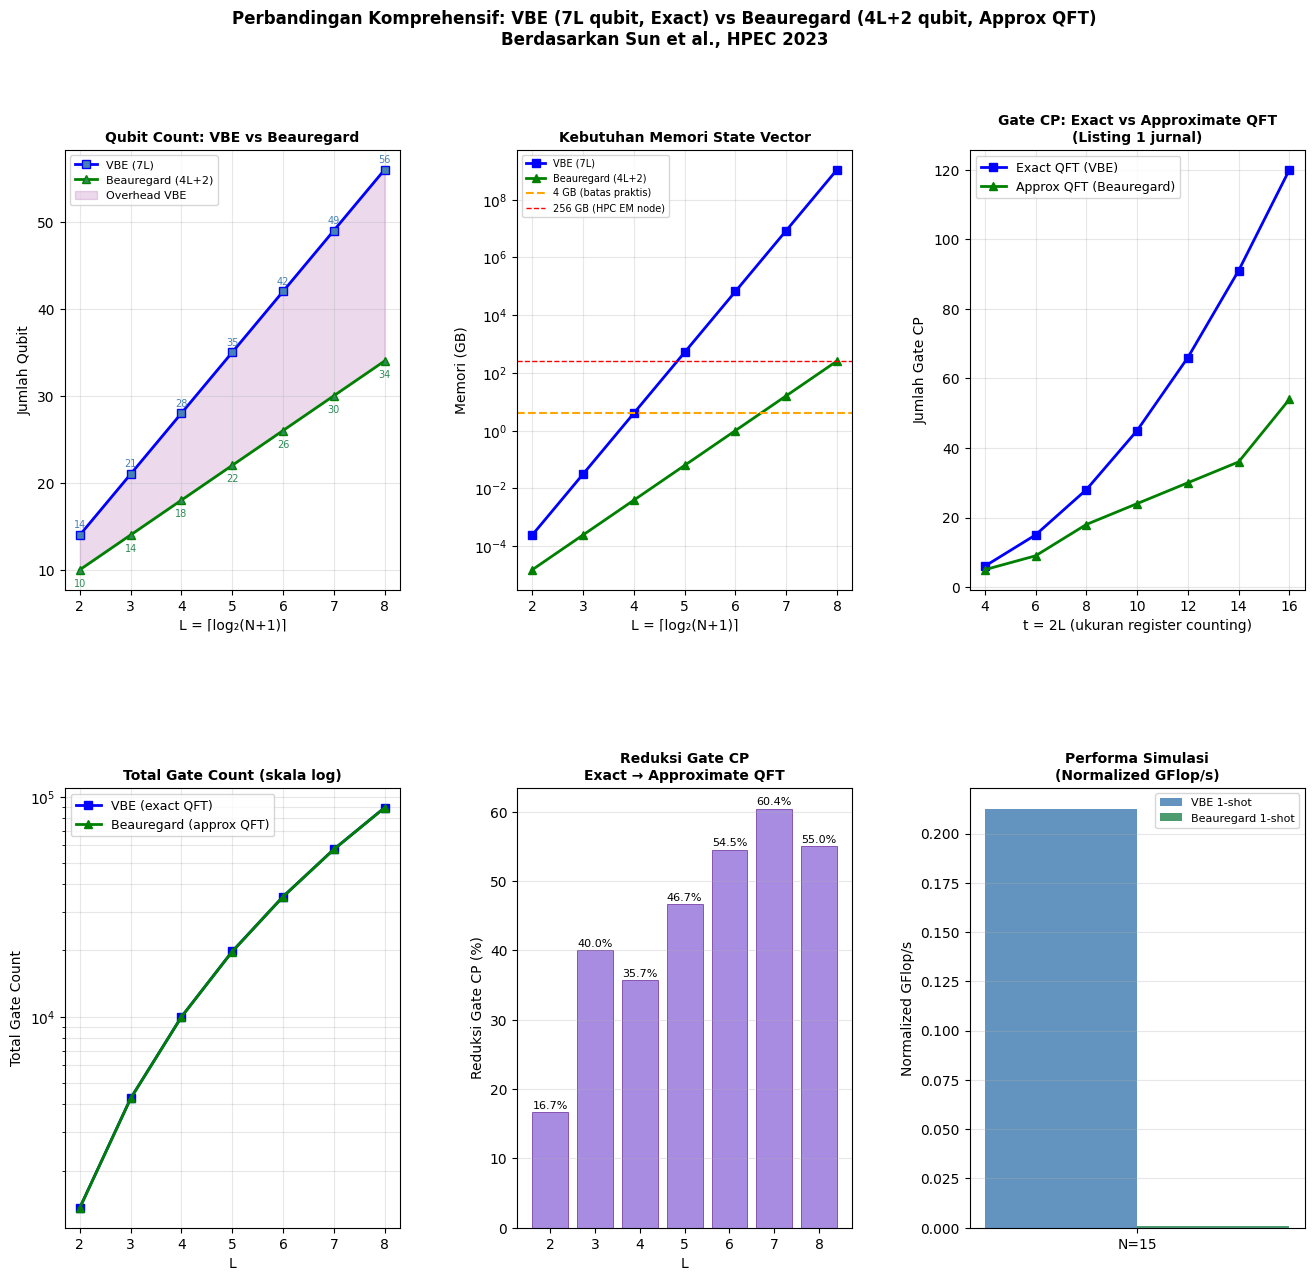

Saved: summary_vbe_vs_beauregard.png


In [ ]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle(
    'Perbandingan Komprehensif: VBE (7L qubit, Exact) vs Beauregard (4L+2 qubit, Approx QFT)\n'
    'Berdasarkan Sun et al., HPEC 2023',
    fontsize=12, fontweight='bold'
)

L_range  = list(range(2, 9))
t_range  = [2 * L for L in L_range]
q_vbe_r  = [qubit_count_vbe(L) for L in L_range]
q_beau_r = [qubit_count_beau(L) for L in L_range]
mem_vbe  = [memory_MB(q) / 1024 for q in q_vbe_r]  # GB
mem_beau = [memory_MB(q) / 1024 for q in q_beau_r]
cp_exact = [gate_count_exact_qft(t) for t in t_range]
cp_approx= [gate_count_approx_qft(t, compute_kmax(t)) for t in t_range]
tot_vbe  = [sum(gate_counts_paper(L).values()) for L in L_range]
tot_beau = [sum(gate_counts_beauregard(L).values()) for L in L_range]


# ── Plot 1: Qubit Count ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(L_range, q_vbe_r,  'b-s', lw=2, ms=6, label='VBE (7L)', markerfacecolor='steelblue')
ax1.plot(L_range, q_beau_r, 'g-^', lw=2, ms=6, label='Beauregard (4L+2)', markerfacecolor='seagreen')
ax1.fill_between(L_range, q_beau_r, q_vbe_r, alpha=0.15, color='purple', label='Overhead VBE')
ax1.set_xlabel('L = ⌈log₂(N+1)⌉', fontsize=10)
ax1.set_ylabel('Jumlah Qubit', fontsize=10)
ax1.set_title('Qubit Count: VBE vs Beauregard', fontweight='bold', fontsize=10)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
for L, q in zip(L_range, q_vbe_r):
    ax1.annotate(f'{q}', (L, q), textcoords='offset points', xytext=(0,5), fontsize=7, ha='center', color='steelblue')
for L, q in zip(L_range, q_beau_r):
    ax1.annotate(f'{q}', (L, q), textcoords='offset points', xytext=(0,-12), fontsize=7, ha='center', color='seagreen')


# ── Plot 2: Kebutuhan Memori (log scale) ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(L_range, mem_vbe,  'b-s', lw=2, ms=6, label='VBE (7L)')
ax2.semilogy(L_range, mem_beau, 'g-^', lw=2, ms=6, label='Beauregard (4L+2)')
ax2.axhline(4,    color='orange', ls='--', lw=1.5, label='4 GB (batas praktis)')
ax2.axhline(256,  color='red',    ls='--', lw=1,   label='256 GB (HPC EM node)')
ax2.set_xlabel('L = ⌈log₂(N+1)⌉', fontsize=10)
ax2.set_ylabel('Memori (GB)', fontsize=10)
ax2.set_title('Kebutuhan Memori State Vector', fontweight='bold', fontsize=10)
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3, which='both')


# ── Plot 3: Gate CP Exact vs Approx ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t_range, cp_exact, 'b-s', lw=2, ms=6, label='Exact QFT (VBE)')
ax3.plot(t_range, cp_approx,'g-^', lw=2, ms=6, label='Approx QFT (Beauregard)')
ax3.set_xlabel('t = 2L (ukuran register counting)', fontsize=10)
ax3.set_ylabel('Jumlah Gate CP', fontsize=10)
ax3.set_title('Gate CP: Exact vs Approximate QFT\n(Listing 1 jurnal)', fontweight='bold', fontsize=10)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)


# ── Plot 4: Total Gate Count (log scale) ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.semilogy(L_range, tot_vbe,  'b-s', lw=2, ms=6, label='VBE (exact QFT)')
ax4.semilogy(L_range, tot_beau, 'g-^', lw=2, ms=6, label='Beauregard (approx QFT)')
ax4.set_xlabel('L', fontsize=10)
ax4.set_ylabel('Total Gate Count', fontsize=10)
ax4.set_title('Total Gate Count (skala log)', fontweight='bold', fontsize=10)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, which='both')


# ── Plot 5: Reduksi Gate CP (%) ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
reductions = [(1 - cp_approx[i]/cp_exact[i])*100 for i in range(len(L_range))]
bars = ax5.bar(L_range, reductions, color='mediumpurple', alpha=0.8, edgecolor='indigo', lw=0.5)
ax5.set_xlabel('L', fontsize=10)
ax5.set_ylabel('Reduksi Gate CP (%)', fontsize=10)
ax5.set_title('Reduksi Gate CP\nExact → Approximate QFT', fontweight='bold', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')
for bar, r in zip(bars, reductions):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{r:.1f}%', ha='center', fontsize=8)


# ── Plot 6: Hasil Simulasi (Correctness & Speedup) ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
if bench_results:
    labels_b = [f'N={r["N"]}' for r in bench_results]
    x_b  = np.arange(len(labels_b))
    w_b  = 0.3
    ax6.bar(x_b - w_b/2, [r['gf_v1'] for r in bench_results], w_b,
            label=f'VBE 1-shot', color='steelblue', alpha=0.85)
    ax6.bar(x_b + w_b/2, [r['gf_b1'] for r in bench_results], w_b,
            label=f'Beauregard 1-shot', color='seagreen', alpha=0.85)
    ax6.set_xticks(x_b); ax6.set_xticklabels(labels_b)
    ax6.set_ylabel('Normalized GFlop/s', fontsize=10)
    ax6.set_title('Performa Simulasi\n(Normalized GFlop/s)', fontweight='bold', fontsize=10)
    ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3, axis='y')
else:
    ax6.text(0.5, 0.5, 'Benchmark belum dijalankan', ha='center', va='center',
             transform=ax6.transAxes, fontsize=11, color='gray')

plt.savefig('summary_vbe_vs_beauregard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: summary_vbe_vs_beauregard.png')

## 12. Kesimpulan Kuantitatif

In [ ]:
print('=' * 70)
print('  RINGKASAN PERBANDINGAN VBE vs BEAUREGARD')
print('  Berdasarkan: Sun et al., HPEC 2023')
print('=' * 70)
print()
print('  Aspek              VBE (Exact)         Beauregard (Approx)')
print('  ─────────────────────────────────────────────────────────')
for L in [4, 5, 6]:
    t       = 2 * L
    kmax    = compute_kmax(t)
    q_v     = qubit_count_vbe(L)
    q_b     = qubit_count_beau(L)
    cp_e    = gate_count_exact_qft(t)
    cp_a    = gate_count_approx_qft(t, kmax)
    red     = (1 - cp_a/cp_e)*100
    ratio_q = q_v / q_b
    N_max   = 2**L - 1
    print(f'  L={L} (N≤{N_max:>3})')
    print(f'  Qubit              {q_v} qubit (7L)         {q_b} qubit (4L+2)  → Beau {ratio_q:.1f}× lebih hemat')
    print(f'  Gate CP (IQFT)     {cp_e} gate (O(t²))     {cp_a} gate (O(t·log t))  → {red:.1f}% berkurang')
    mem_v = memory_MB(q_v)/1024; mem_b = memory_MB(q_b)/1024
    print(f'  Memori             {mem_v:.0f} GB                {mem_b:.3f} GB  → {mem_v/mem_b:.0f}× lebih hemat')
    print(f'  kmax (approx)      —                    {kmax} (floor(log₂({t})))')
    print()

  RINGKASAN PERBANDINGAN VBE vs BEAUREGARD
  Berdasarkan: Sun et al., HPEC 2023

  Aspek              VBE (Exact)         Beauregard (Approx)
  ─────────────────────────────────────────────────────────
  L=4 (N≤ 15)
  Qubit              28 qubit (7L)         18 qubit (4L+2)  → Beau 1.6× lebih hemat
  Gate CP (IQFT)     28 gate (O(t²))     18 gate (O(t·log t))  → 35.7% berkurang
  Memori             4 GB                0.004 GB  → 1024× lebih hemat
  kmax (approx)      —                    3 (floor(log₂(8)))

  L=5 (N≤ 31)
  Qubit              35 qubit (7L)         22 qubit (4L+2)  → Beau 1.6× lebih hemat
  Gate CP (IQFT)     45 gate (O(t²))     24 gate (O(t·log t))  → 46.7% berkurang
  Memori             512 GB                0.062 GB  → 8192× lebih hemat
  kmax (approx)      —                    3 (floor(log₂(10)))

  L=6 (N≤ 63)
  Qubit              42 qubit (7L)         26 qubit (4L+2)  → Beau 1.6× lebih hemat
  Gate CP (IQFT)     66 gate (O(t²))     30 gate (O(t·log t))  → 54.5% be